We're going to run a grid of stars from 15+ solar masses for a range of metallicities to assess what masses lead to BH formation in COSMIC.

In [1]:
from cosmic.sample.initialbinarytable import InitialBinaryTable
from cosmic.evolve import Evolve
import numpy as np
import matplotlib.pyplot as plt
import cogsworth
from multiprocessing import Pool
import pandas as pd

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

Create two grids to handle most metallicities and high metallicities separately

In [62]:
initial_binaries = None

for step, m_min, m_max, Z_min, Z_max in [
    (0.025, 16, 22, 1e-4, 2e-2),
    (0.5, 22, 80, 1.6e-2, 0.03),
]:

    mass_range = np.arange(m_min, m_max + step, step)
    metallicity_grid = np.geomspace(1e-4, 0.03, 200)
    metallicity_grid = metallicity_grid[(metallicity_grid >= Z_min) & (metallicity_grid <= Z_max)]

    M, Z = np.meshgrid(mass_range, metallicity_grid, indexing='ij')
    m_flat = M.ravel()
    z_flat = Z.ravel()
    binaries = InitialBinaryTable.InitialBinaries(
        m1=M.ravel(),
        m2=np.zeros(len(m_flat)),
        porb=-1 * np.ones(len(m_flat)),
        ecc=-1 * np.ones(len(m_flat)),
        tphysf=13700 * np.ones(len(m_flat)),
        kstar1=np.ones(len(m_flat)),
        kstar2=np.zeros(len(m_flat)),
        metallicity=z_flat,
    )
    
    if initial_binaries is None:
        initial_binaries = binaries
    else:
        initial_binaries = pd.concat([initial_binaries, binaries], ignore_index=True)

initial_binaries.sort_values(by='metallicity', inplace=True)

len(initial_binaries)

47159

In [63]:
initial_binaries["bin_num"] = initial_binaries.index

In [64]:
from cosmic.utils import parse_inifile
BSEDict, SSEDict, _, _, _, _ = parse_inifile("../simulations/params.ini")

In [65]:
bpp, bcm, initC, kick_info = Evolve.evolve(initial_binaries, nproc=32, SSEDict=SSEDict, BSEDict=BSEDict, progress=True)
final_bpp = bpp.drop_duplicates(subset="bin_num", keep="last")

Evolving: 100%|██████████| 47159/47159 [01:01<00:00, 767.18sys/s] 


In [66]:
# find the minimum initial mass in initC where final_bpp has kstar_1 == 13
exploding_stars = final_bpp[final_bpp["kstar_1"] == 14]
exploding_initC = initC[initC["bin_num"].isin(exploding_stars["bin_num"])]
min_exploding_mass = exploding_initC.groupby("metallicity")["mass_1"].min().reset_index()
min_exploding_mass.to_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass", mode="w")

<Axes: title={'center': 'Minimum Initial Mass for Core-Collapse vs Metallicity'}, xlabel='Metallicity', ylabel='Minimum Initial Mass for Core-Collapse (M$_\\odot$)'>

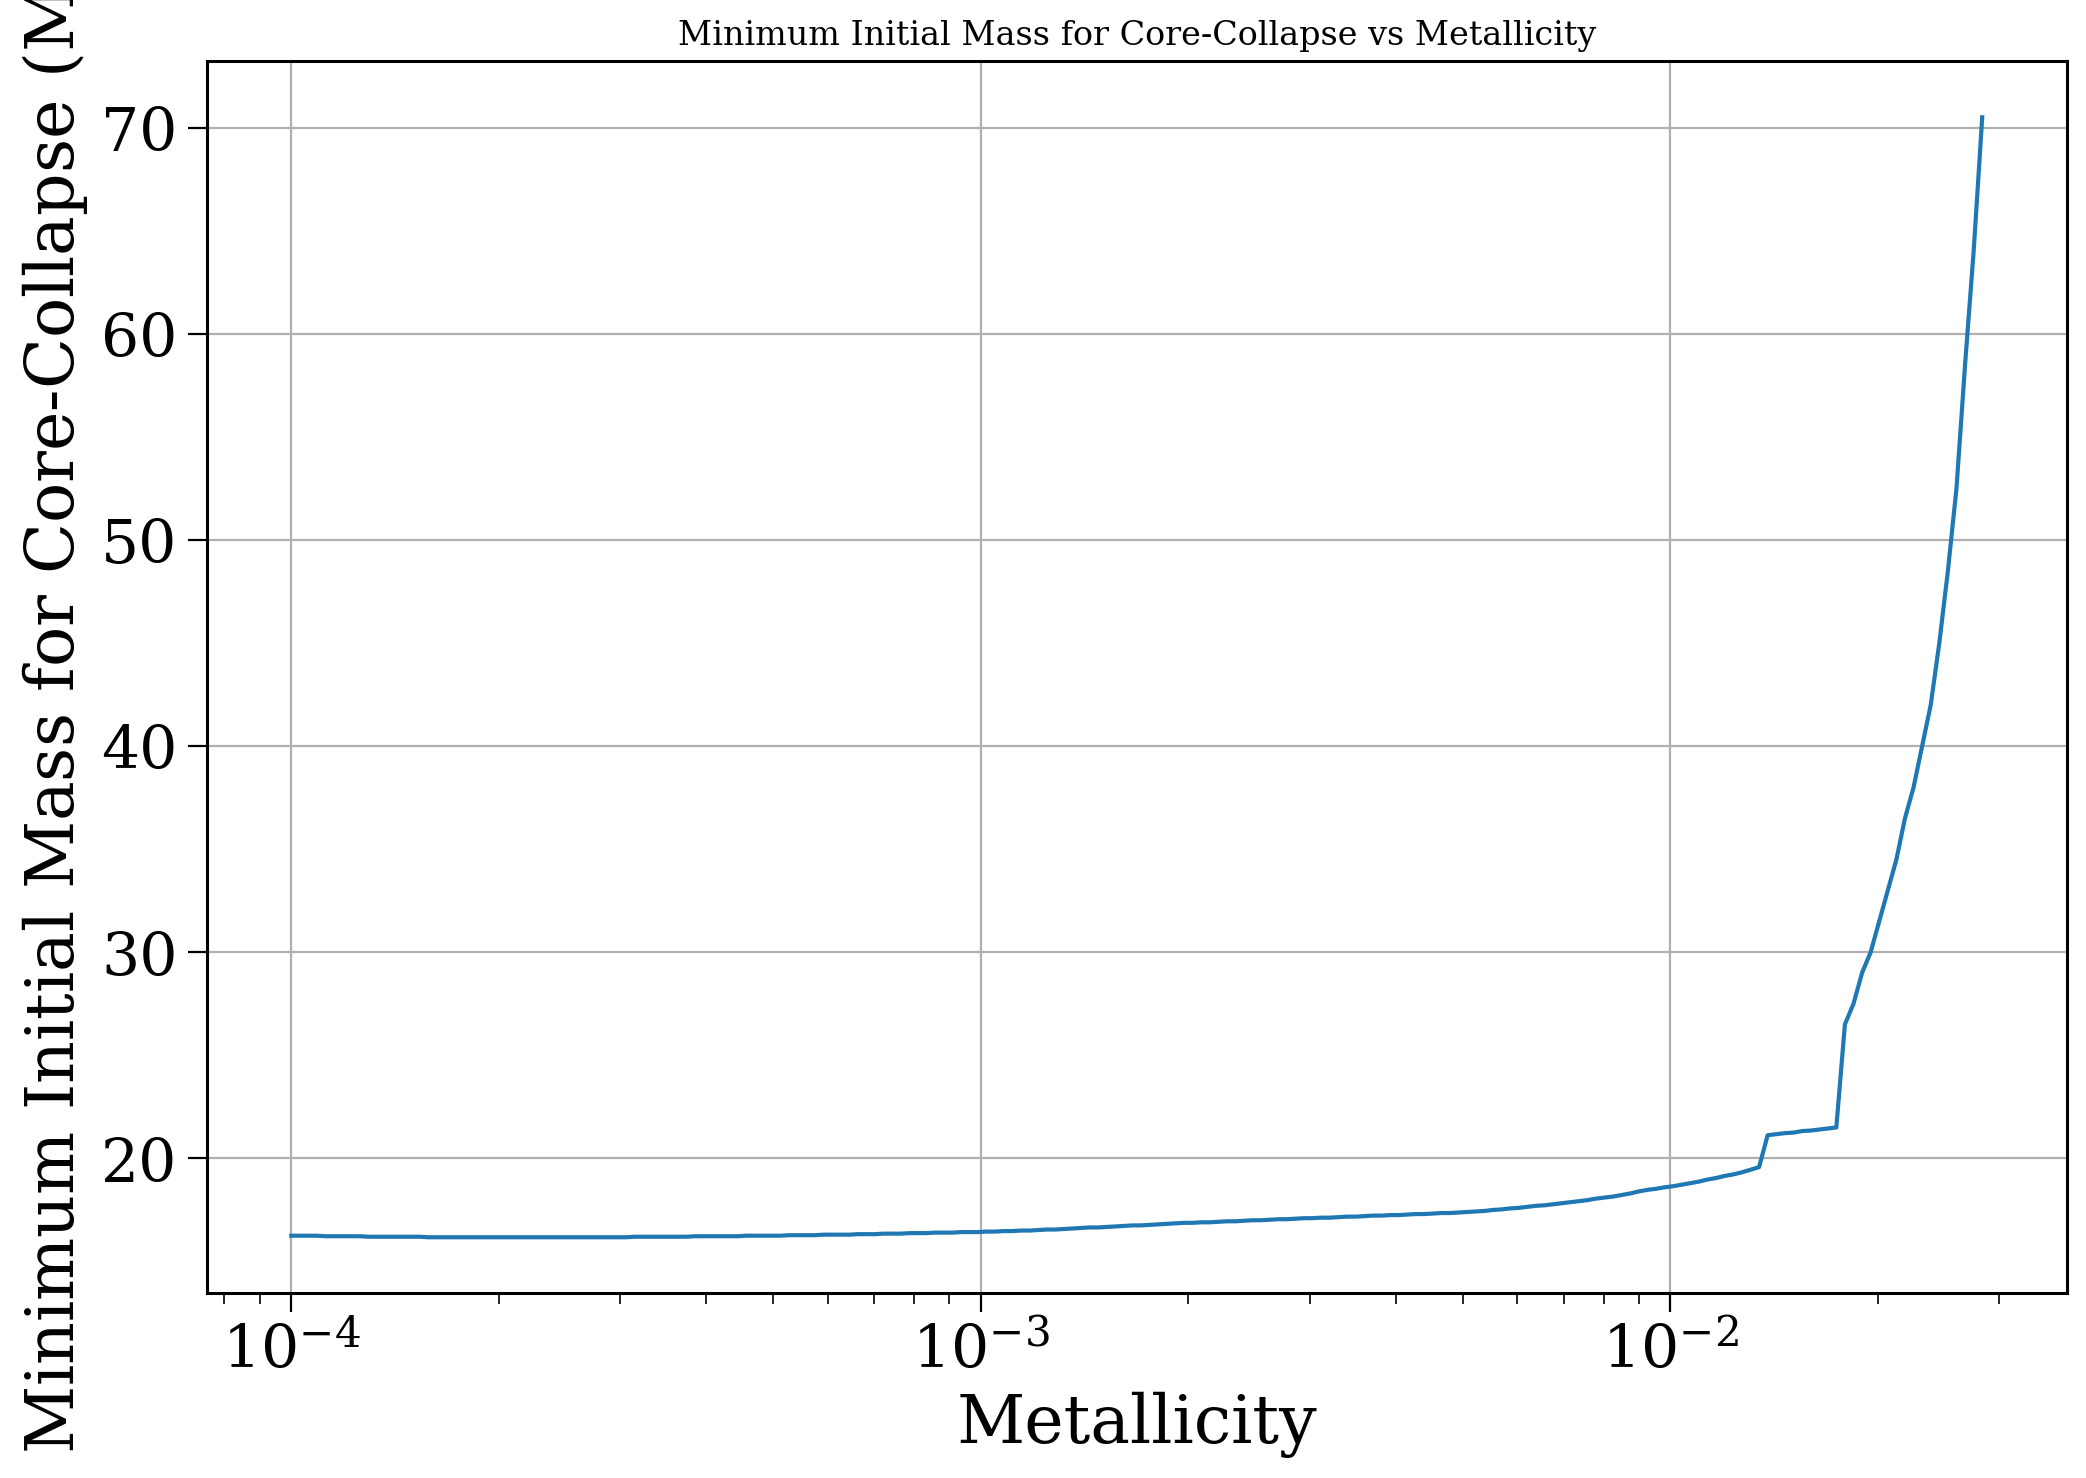

In [67]:
min_exploding_mass.plot(
    x="metallicity",
    y="mass_1",
    logx=True,
    xlabel="Metallicity",
    ylabel="Minimum Initial Mass for Core-Collapse (M$_\odot$)",
    title="Minimum Initial Mass for Core-Collapse vs Metallicity",
    legend=False,
    grid=True,
)

In [68]:
# find things in initC with metallicity between 0.02 and 0.03 and mass_1 between 70 and 72
initC[(initC["metallicity"] >= 0.02) & (initC["metallicity"] <= 0.03) & (initC["mass_1"] >= 70) & (initC["mass_1"] <= 72)]

,kstar_1,kstar_2,mass_1,mass_2,porb,ecc,metallicity,binfrac,tphysf,mass0_1,...,fprimc_10,fprimc_11,fprimc_12,fprimc_13,fprimc_14,fprimc_15,alpha1_0,alpha1_1,acc_lim_0,acc_lim_1
46770,1.0,0.0,71.5,0.0,-1.0,-1.0,0.020084,1.0,13700.0,71.5,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46792,1.0,0.0,72.0,0.0,-1.0,-1.0,0.020084,1.0,13700.0,72.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46726,1.0,0.0,70.5,0.0,-1.0,-1.0,0.020084,1.0,13700.0,70.5,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46704,1.0,0.0,70.0,0.0,-1.0,-1.0,0.020084,1.0,13700.0,70.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46748,1.0,0.0,71.0,0.0,-1.0,-1.0,0.020084,1.0,13700.0,71.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46806,1.0,0.0,72.0,0.0,-1.0,-1.0,0.030000,1.0,13700.0,72.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46718,1.0,0.0,70.0,0.0,-1.0,-1.0,0.030000,1.0,13700.0,70.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46784,1.0,0.0,71.5,0.0,-1.0,-1.0,0.030000,1.0,13700.0,71.5,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1
46762,1.0,0.0,71.0,0.0,-1.0,-1.0,0.030000,1.0,13700.0,71.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,1.0,1.0,-1,-1


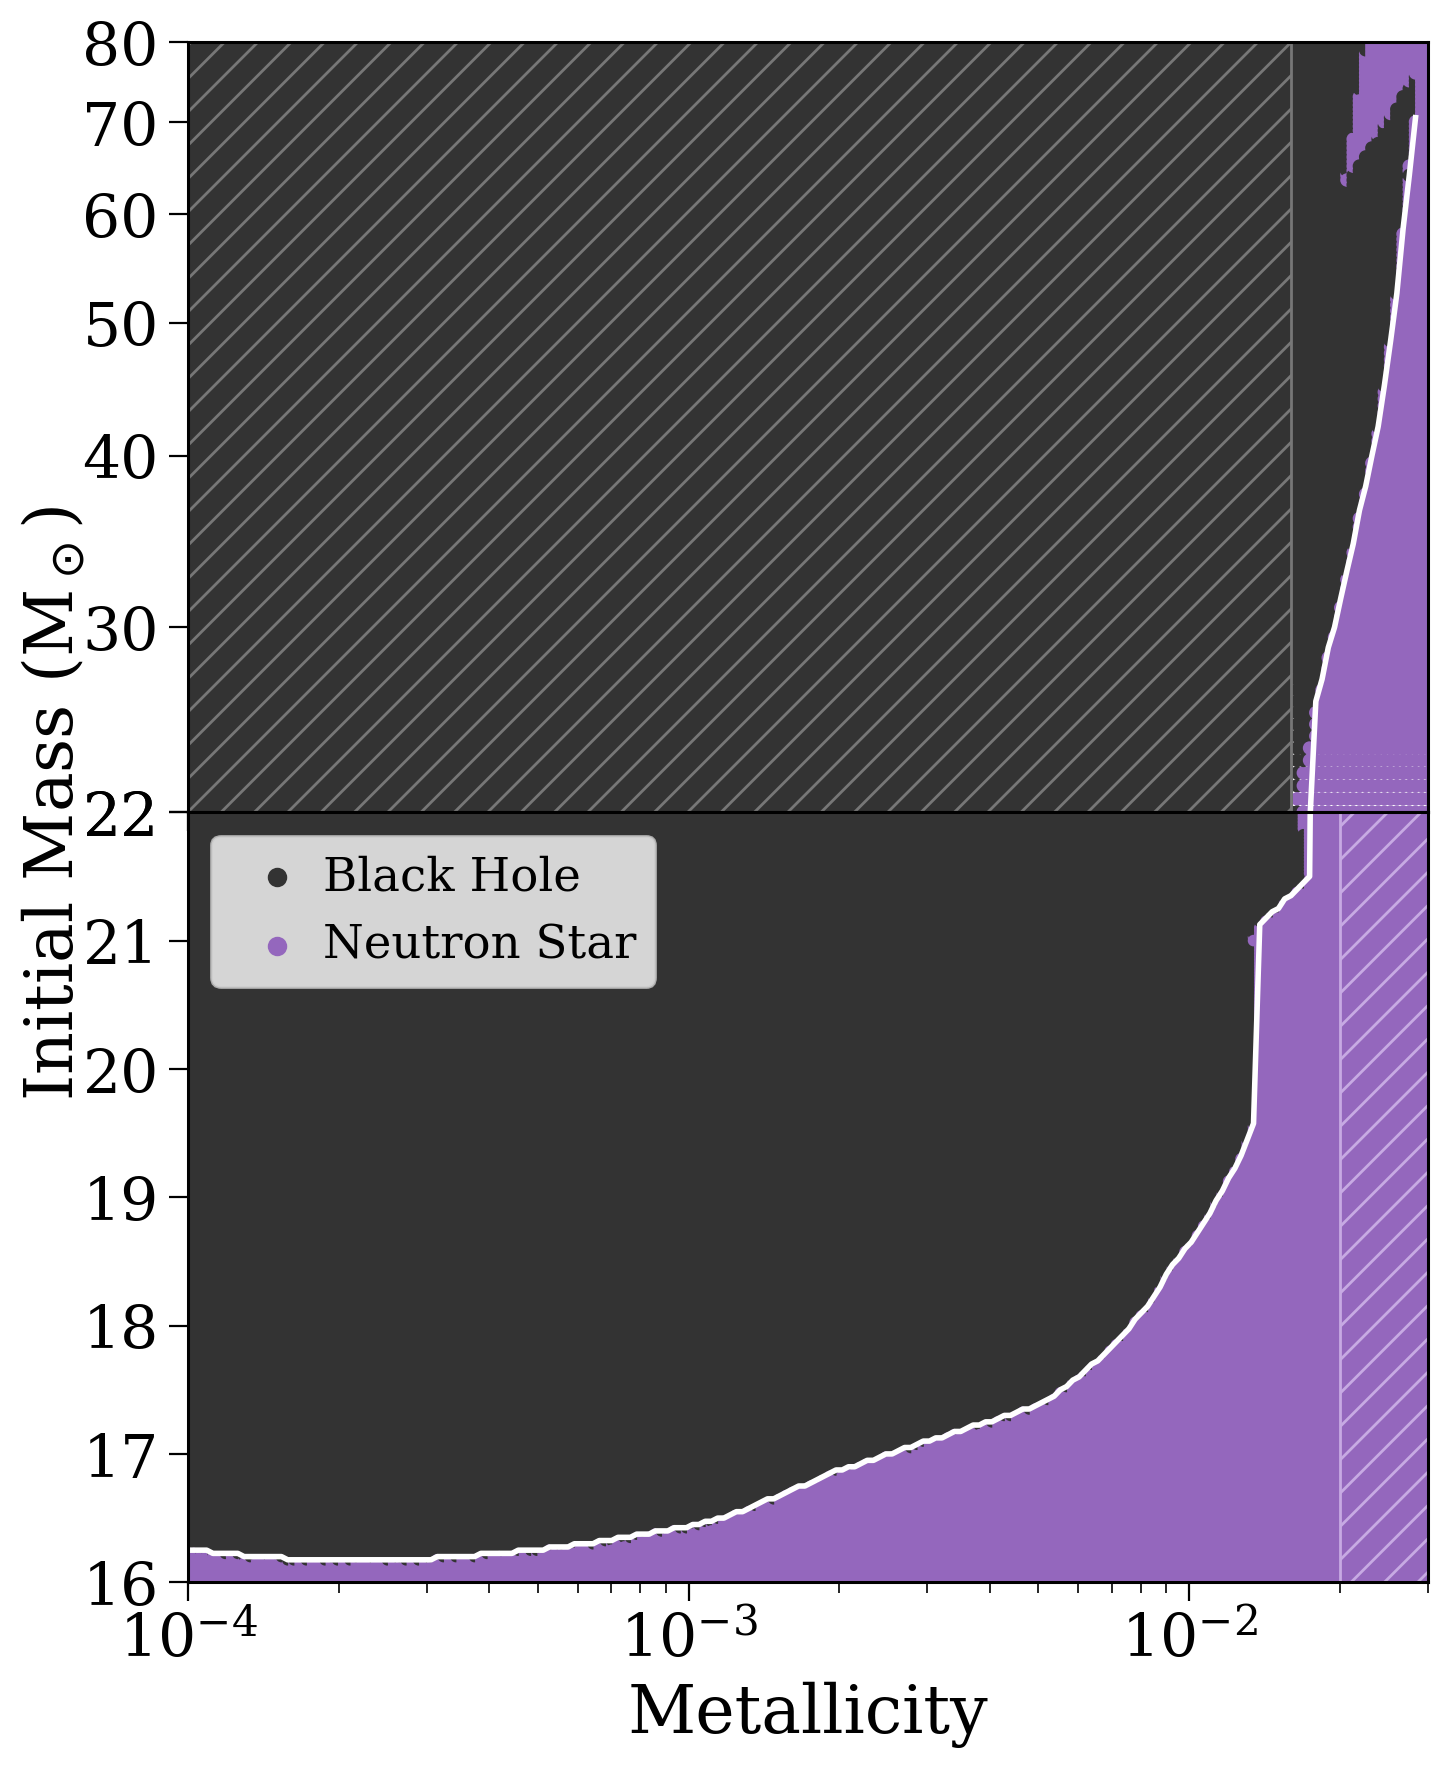

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

fig.subplots_adjust(hspace=0.0)

for ax, m_lims, scale, s in zip(axes, [(22, 80), (16, 22)], ['log', 'linear'], [15, 10]):
    ax.scatter(initC["metallicity"], initC["mass_1"],
            c=colours,
            s=s,
            rasterized=True)

    ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
            color='white', lw=2)

    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [80, 80],
        color='#333',
    )
    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [80, 80],
        facecolor='none',
        edgecolor="#777777",
        hatch='//',
    )

    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        color='tab:purple',
    )
    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        facecolor='none',
        edgecolor="#c7aae3",
        hatch='//',
    )

    for k in [14, 13]:
        ax.scatter(
            np.nan, np.nan,
            c="#333" if k == 14 else "tab:purple",
            label=cogsworth.utils.kstar_translator[k]["long"],
        )

    ax.set(
        xlabel="Metallicity" if ax == axes[-1] else "",
        # ylabel="Initial Mass (M$_\odot$)",
        xscale="log",
        yscale=scale,
        xlim=(1e-4, 0.03),
        ylim=m_lims,
    )

axes[0].set_yticks([22, 30, 40, 50, 60, 70, 80])
axes[0].set_yticklabels([22, 30, 40, 50, 60, 70, 80])
axes[1].legend(loc='upper left', handletextpad=0.0, ncol=1)

fig.supylabel("Initial Mass (M$_\odot$)", fontsize=fs)

plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()